In [1]:
import os
import glob
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, 
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

print("imports ok")

imports ok


In [12]:
# RECHARGEMENT DES DONNÉES (depuis Tache 1)
SEED     = 42
CLASSES  = ['glioma', 'meningioma', 'notumor', 'pituitary']
BASE_DIR = "brain-tumor-mri-dataset"
IMG_SIZE = (256, 256)

random.seed(SEED)
np.random.seed(SEED)

X_train, y_train = [], []
X_test, y_test   = [], []

for cls in CLASSES:
    for split, X_list, y_list in [('Training', X_train, y_train),
                                   ('Testing', X_test, y_test)]:
        folder = os.path.join(BASE_DIR, split, cls)
        for f in os.listdir(folder):
            img = cv2.imread(os.path.join(folder, f), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, IMG_SIZE)
            X_list.append(img)
            y_list.append(cls)

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test  = np.array(X_test)
y_test  = np.array(y_test)

# normalisation
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm  = X_test.astype('float32')  / 255.0

# encodage des labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print(f"train : {X_train_norm.shape[0]} images")
print(f"test  : {X_test_norm.shape[0]} images")

train : 5600 images
test  : 1600 images


In [13]:
# Aplatissement des images pour la RegLog
# la reglog peut pas travailler avec des images 2D
# on aplatit chaque image en un vecteur
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat  = X_test_norm.reshape(X_test_norm.shape[0], -1)

print(f"shape après aplatissement : {X_train_flat.shape}")

# standardscaler pour que toutes les features soient sur la meme echelle
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_flat)
X_test_sc  = scaler.transform(X_test_flat)

print("scaling ok")

shape après aplatissement : (5600, 65536)
scaling ok


In [14]:
# modèle de base sans calibration
reglog = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=SEED)
reglog.fit(X_train_sc, y_train_enc)

y_pred_rl = reglog.predict(X_test_sc)
acc_rl    = accuracy_score(y_test_enc, y_pred_rl)
print(f"accuracy sans calibration : {acc_rl:.4f}")

accuracy sans calibration : 0.7900


In [15]:
# modèle avec calibration (Platt Scaling)
# on applique le platt scaling pour avoir des probabilites fiables
reglog_cal = CalibratedClassifierCV(
    estimator=LogisticRegression(solver='lbfgs', max_iter=1000, random_state=SEED),
    method='sigmoid',
    cv=5
)
reglog_cal.fit(X_train_sc, y_train_enc)

y_pred_cal = reglog_cal.predict(X_test_sc)
acc_cal    = accuracy_score(y_test_enc, y_pred_cal)

print(f"accuracy sans calibration : {acc_rl:.4f}")
print(f"accuracy avec calibration : {acc_cal:.4f}")

accuracy sans calibration : 0.7900
accuracy avec calibration : 0.8013


In [16]:
# Rapport de classification
print(classification_report(y_test_enc, y_pred_cal, target_names=le.classes_))

              precision    recall  f1-score   support

      glioma       0.76      0.68      0.72       400
  meningioma       0.72      0.75      0.74       400
     notumor       0.85      0.97      0.91       400
   pituitary       0.86      0.81      0.83       400

    accuracy                           0.80      1600
   macro avg       0.80      0.80      0.80      1600
weighted avg       0.80      0.80      0.80      1600



commentaire : Le glioma a le recall le plus faible (0.68) le modèle rate 32% des tumeurs malignes.
C'est inacceptable et très dangereux pour un SAD médical,on aurait besoin d'un modèle(CNN) plus performant et puissant d'un moteur de décision avec des seuils de sécurité stricts.

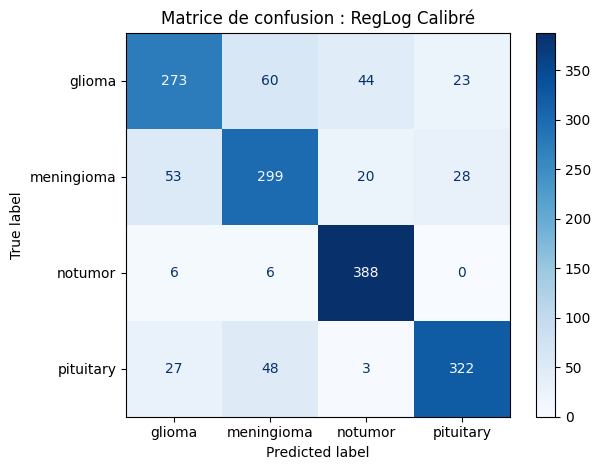

In [17]:
#matrice de confusion
cm = confusion_matrix(y_test_enc, y_pred_cal)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Matrice de confusion : RegLog Calibré")
plt.tight_layout()
plt.show()

cas incertains (max_prob < 0.7) : 784 / 1600
soit 49.0% des prédictions


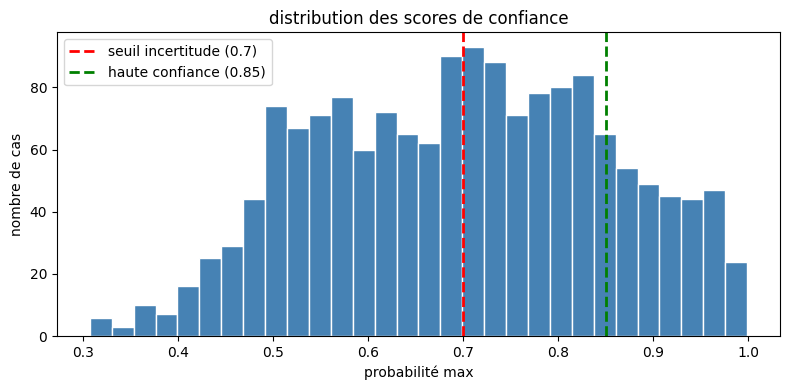

In [18]:
# probabilités pour chaque image
proba_cal = reglog_cal.predict_proba(X_test_sc)

# probabilité max = niveau de confiance du modèle
max_prob = proba_cal.max(axis=1)

# cas incertains : modèle pas sûr à 70%
incertains = max_prob < 0.7
print(f"cas incertains (max_prob < 0.7) : {incertains.sum()} / {len(max_prob)}")
print(f"soit {incertains.mean()*100:.1f}% des prédictions")

# visualisation
plt.figure(figsize=(8, 4))
plt.hist(max_prob, bins=30, color='steelblue', edgecolor='white')
plt.axvline(0.7, color='red', ls='--', lw=2, label='seuil incertitude (0.7)')
plt.axvline(0.85, color='green', ls='--', lw=2, label='haute confiance (0.85)')
plt.title("distribution des scores de confiance")
plt.xlabel("probabilité max")
plt.ylabel("nombre de cas")
plt.legend()
plt.tight_layout()
plt.show()